# Modèles non supervisés

## Liste des modèles utilisés :
    - DBSCAN
    - KMEANS
    - SpectralClustering

##### Dans ce notebook nous essayerons d'établir le nombre optimal de clusters avec un DataSet donné (Student_Dataset.csv)

## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from stop_words import get_stop_words

# Sklearn import
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD

## Nos modèles

### KMEANS

##### Pour le KMEANS nous allons essayer de déterminer le nombre optimal de dimensions à utiliser ainsi que le nombre optimal de clusters.
On va regarder entre 10 et 20 dimensions pour le `TruncatedSVD`. 

Pourquoi pas plus ?
Entre 10 et 20 dimensions on garde entre ~ 9% et ~ 18% des informations. (À titre de comparaison 40 dimensions donnent ~ 21 % des informations conservées)

Nous avons donc choisi d'avoir moins d'informations pour garder le moins de bruit possible et d'avoir les clusters les plus généraux possible. Plus le nombre de dimensions est élevé plus le silhouette score est faible mais le nombre de clusters change également, il ne devient pas faux mais plus précis.


Ensuite pour chaque essai de dimension on va essayer de séparer entre 2 et 50 clusters.
Nous ne prenons pas plus de 50 clusters car 50 est dérisoire, nous n'avons pas 50 groupes de problèmes surtout que nous cherchons des clusters généraux comme expliqué avant. (Nous laissons 50 car le nombre de clusters n'augmente pas énormément la puissance de calcul nécessaire).

Pour chaque essai on affiche le % d'informations gardé avec les dimensions et à la fin on affiche le meilleur score de silhouette, une visualisation sur 3 dimensions ainsi que le coude.

Pour 36 dimensions, on conserve 19.73% de l'information (variance).
Pour 35 dimensions, on conserve 19.39% de l'information (variance).
0.2040309609683189
17
Inertie correspondante : 115.7053102692983


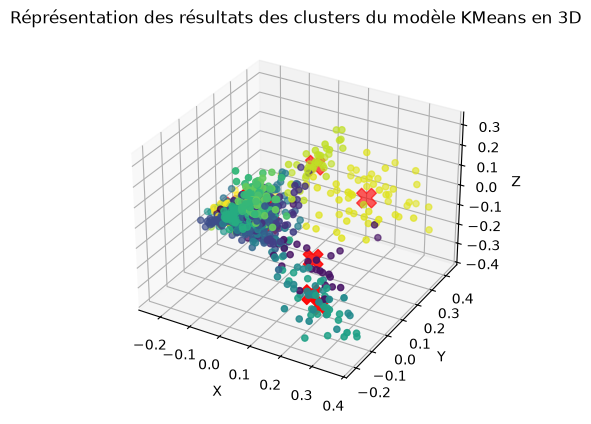

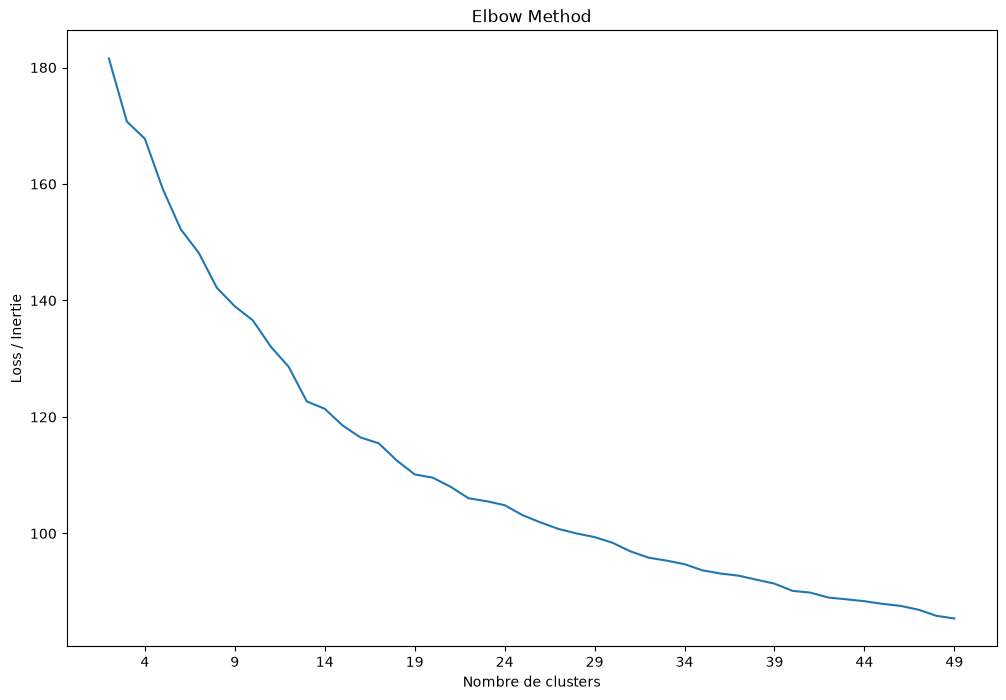

In [3]:
try:
    df = pd.read_csv("../../Student_Clean.csv")
except FileNotFoundError:
    print("Fichier non trouve")
    raise SystemExit(84)

#Récupère les textes et remplace les NA par des ""
texts = df["Temoignage"].fillna("")


#Créer mon TF-IDF (Term frequency inverse document frequency) en retirant les stop_words
vectorizer = TfidfVectorizer(stop_words="english")
X_tp = vectorizer.fit_transform(texts) #Transforme les mots en valeurs et regarde si chaque phrase possède ces mots pour leur donner un score

# sauvegarde des valeurs pour les meilleurs paramètres
Best_N_Compo = 21
Best_H_Score = -1
Best_H_Key = 0
actual_N = 21
Best_inertia = 0

# Boucler sur le paramètre `n_components` de `TruncatedSVD` entre 20 et 10 pour limiter les dimensions créées par le TfidfVectorizer
while actual_N >= 10:
    actual_N-=1
    # Utilisation d'un`TruncatedSVD` car le TF-IDF fait énormément de dimensions, pour garder une cohérence et une faisabilité avec le modèle KMEANS on va en garder 50
    svd = TruncatedSVD(n_components=actual_N, random_state=42)
    X = svd.fit_transform(X_tp)
    print(f"Pour {actual_N} dimensions, on conserve {svd.explained_variance_ratio_.sum() * 100:.2f}% de l'information.")
    
    #Teste chaque nombre de clusters entre 2 et 50 puis ajoute les scores dans un dico et enfin print le meilleur score de ce dico afin de connaître la meilleure valeur pour le nombre de clusters
    scores = {}
    inertias = {}
    for n in range(2, 50):
        kmeans = KMeans(
            n_clusters=n,
            random_state=0,
            n_init="auto", #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
        )
        Y = kmeans.fit_predict(X)
        inertias[f"{n}"] = kmeans.inertia_
        score = silhouette_score(X, Y, metric="cosine") # Regarde si les points sont proches de leurs centroïdes et s'ils sont éloignés des autres clusters puis donne un score en fonction du résultat
        scores[f"{n}"] = score
    
    highest_key = max(scores, key=scores.get)

    # si le score actuel est le meilleur jamais vu alors on sauvegarde les valeurs
    if (Best_H_Score < scores[highest_key]):
        Best_H_Score = scores[highest_key]
        Best_N_Compo = actual_N
        Best_H_Key = highest_key
        Best_inertia = inertias[highest_key]
    
    
    # ================================================================= #
    
    # Créer mon KMeans avec le meilleur nombre de clusters
    
    kmeans = KMeans(
            n_clusters=int(highest_key),
            random_state=0,
            n_init="auto" #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
        )
    
    #Entraîne le modèle sur nos témoignages d'entrée médicale à l'hôpital
    Y = kmeans.fit_predict(X)


# on affiche les meilleurs résultats dans tout ça
print(Best_H_Score)
print(Best_H_Key)
print("Inertie correspondante :", Best_inertia)


svd_final = TruncatedSVD(n_components=Best_N_Compo, random_state=42)
X_final = svd_final.fit_transform(X_tp)

# 2. On recrée le KMeans avec le MEILLEUR nombre de clusters trouvé
kmeans_final = KMeans(
    n_clusters=int(Best_H_Key),
    random_state=0,
    n_init="auto"
)
Y_final = kmeans_final.fit_predict(X_final)


#Créer la figure 
fig = plt.figure()

#Créer l'axe en 3D 
axe = fig.add_subplot(111, projection="3d")

#Le TF-IDF a potentiellement plein de dimensions genre si on lui donne 10000 mots il peut potentiellement avoir 10000 dimensions PCA fait en sorte de ne prendre qu'une représentation avec le nombre de dimensions donné
pca = PCA(n_components=3)

#Transforme le vecteur de mes textes en vecteur 3D
points_3d = pca.fit_transform(X)

#Transforme le vecteur des centroïdes de mes clusters en vecteur 3D
centroïdes_3d = pca.transform(kmeans.cluster_centers_)

#Affiche tous mes points en 3D
axe.scatter(
    points_3d[:, 0],
    points_3d[:, 1],
    points_3d[:, 2],
    c=Y
)

#Affiche tous mes centroïdes en 3D
axe.scatter(
    centroïdes_3d[:, 0],
    centroïdes_3d[:, 1],
    centroïdes_3d[:, 2],
    marker="X",
    s=200,
    c="red"
)

#Nomme les axes
plt.title('Réprésentation des résultats des clusters du modèle KMeans en 3D')
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

#Affiche le graphique
plt.show()


fig = plt.figure(figsize=(12, 8))
plt.xticks(range(2, 51, 5))
plt.plot(inertias.keys(), inertias.values())
plt.xlabel("Nombre de clusters")
plt.ylabel("Loss / Inertie")
plt.title("Elbow Method")
plt.show()



On voit donc ici une représentation du coude et d'une représentation 3D, on peut donc voir qu'on obtient ~ 8 clusters.
La représentation 3D permet d'avoir une idée, mais assez réduite due à la nature et au nombre de dimensions réel.

Pour notre coude, il permet de voir le rapport innertie et nombre de clusters, et de valider visuellement le nombre de clusters

#### Vérification des contenus dans les clusters

Pour comprendre nos résultats on va afficher les 3 premiers témoignages de chaque cluster.
Les chiffres sont clés mais la vérification humaine reste une méthode infaillible pour établir la pertinence des clusters

In [18]:
df["Cluster"] = Y

for i in range(int(highest_key)):
    print(f"\n CLUSTER {i} ")
    
    # on cherche pour n'avoir que ceux du cluster i
    cluster_actuel = df[df["Cluster"] == i]

    textes = cluster_actuel["Temoignage"]
    
    # on prend les 3 premiers
    trois_premiers = textes.head(3)
    
    # on affiche les 3 premiers
    for text in trois_premiers:
        print(text)


 CLUSTER 0 
A short sprint brought on a twinge in the middle of the back of my thigh. It's tender along a band and stiffens if I sit too long.
A sudden twist while reaching for a bag made one side of my lower back feel ‘switched off' and sore. Small stabilizing movements feel shaky.
I slipped on ice and landed seated. Since then sitting on hard chairs is very uncomfortable, and leaning slightly forward helps. Standing up from sitting is a careful process.

 CLUSTER 1 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
While working in the garden, I touched a metal grill that had been on the stove. My left forearm has a burning itch and a faint scar.
On the sole, a painful spot feels like stepping on a stone. The surface is rough with tiny dark dots

 CLUSTER 2 
I noticed a rash on my forearms after handling a new brand of sunscreen. The spots are itchy and raise

#### On voit donc que les clusters sont assez bien et pertinents mais certains sont trop généraux par exemple le 01 :
```
 CLUSTER 1 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
While working in the garden, I touched a metal grill that had been on the stove. My left forearm has a burning itch and a faint scar.
On the sole, a painful spot feels like stepping on a stone. The surface is rough with tiny dark dots
```
##### On a de la toux avec une brûlure ce n'est pas logique.

### DBSCAN

Petit rappel de la structure :
```
class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
```

Pour la réflexion et l'analyse derrière l'utilisation du modèle DBSCAN se référencer au fichier `DBSCAN.md`

Test avec:  {5}
Test eps=0.24 | min_samples=5 | Clusters: 2 | Bruit: 968 | Silhouette: -0.0292
Test eps=0.25 | min_samples=5 | Clusters: 3 | Bruit: 957 | Silhouette: -0.0485
Test eps=0.26 | min_samples=5 | Clusters: 3 | Bruit: 945 | Silhouette: -0.0467
Test eps=0.27 | min_samples=5 | Clusters: 4 | Bruit: 922 | Silhouette: -0.0712
Test eps=0.28 | min_samples=5 | Clusters: 4 | Bruit: 896 | Silhouette: -0.0567
Test eps=0.29 | min_samples=5 | Clusters: 7 | Bruit: 862 | Silhouette: -0.1041
Test eps=0.30 | min_samples=5 | Clusters: 2 | Bruit: 831 | Silhouette: 0.0037
Test eps=0.31 | min_samples=5 | Clusters: 2 | Bruit: 800 | Silhouette: 0.0072
Test eps=0.32 | min_samples=5 | Clusters: 3 | Bruit: 751 | Silhouette: -0.0443
Test eps=0.33 | min_samples=5 | Clusters: 3 | Bruit: 704 | Silhouette: -0.0746
Test eps=0.34 | min_samples=5 | Clusters: 3 | Bruit: 655 | Silhouette: -0.0632
Test eps=0.35 | min_samples=5 | Clusters: 5 | Bruit: 601 | Silhouette: -0.1099
Test eps=0.36 | min_samples=5 | Cluste

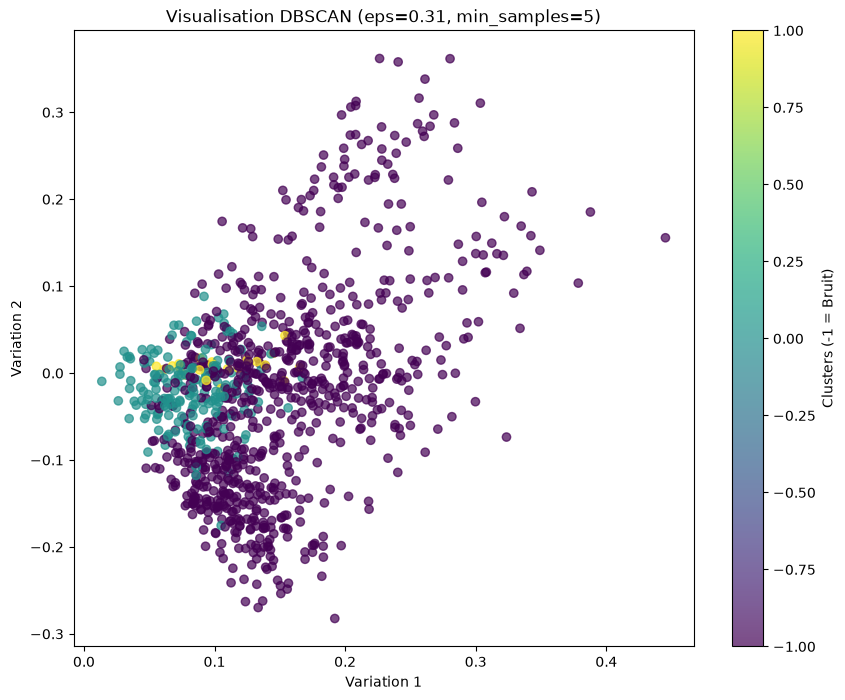

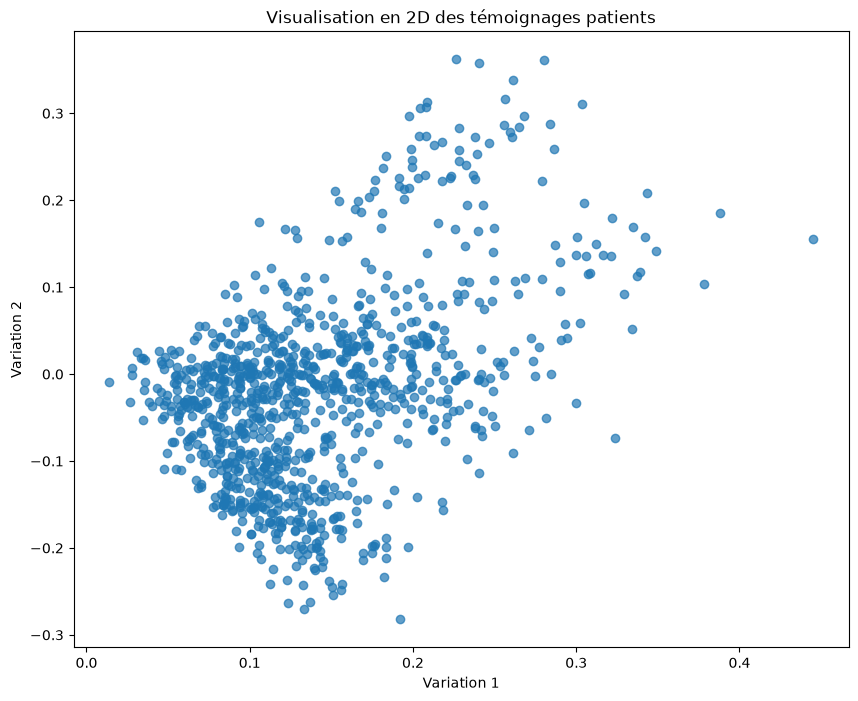

In [3]:
try:
    dfAll = pd.read_csv('../../Student_Clean.csv')
except FileNotFoundError:
    print("Fichier non trouve")
    raise SystemExit(84)
X = dfAll['Temoignage']
try:
    df = pd.read_csv("../../Student_Clean.csv")
except FileNotFoundError:
    print("Fichier non trouve")
    raise SystemExit(84)


# on prend les témoignages et on gère les fillna au cas où
texts = df['Temoignage'].fillna("")


# TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")
X_t = vectorizer.fit_transform(texts)

# réduction du nombre de dimensions
svd = TruncatedSVD(n_components=50, random_state=42)
X = svd.fit_transform(X_t)




def Training(eps, min_s):
    """
    Entraîne le modèle avec eps et min_samples en parametre.
    Renvoie le score de silhouette ou -1 si impossible.
    """
    db = DBSCAN(eps=eps, min_samples=min_s).fit(X)
    labels = db.labels_
    
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    
    if n_clusters_ > 1:
        silhouette = silhouette_score(X, labels, metric="cosine")
        print(f"Test eps={eps:.2f} - min_samples={min_s} - Clusters: {n_clusters_} - Bruit: {n_noise_} - Silhouette: {silhouette:.4f}")
        return silhouette
    else:
        return -1




# entrainement avec notre double boucle
best_eps = 0
best_min_samples = 0
best_value = -1

# On teste 4 valeurs logiques pour min_samples
valeurs_min_samples = [5, 10, 15, 20]

for min_s in valeurs_min_samples:
    print("Test avec: ",{min_s})
    
    tp = 0.01
    end = 2.0
    
    while tp < end:
        silhouette_Resultat = Training(tp, min_s)
        
        if silhouette_Resultat > best_value:
            best_value = silhouette_Resultat
            best_eps = tp
            best_min_samples = min_s
            
        tp = round(tp + 0.01, 2) # round pour éviter les bugs de décimales en Python


print(f"Meilleurs paramètres : eps={best_eps}, min_samples={best_min_samples}")
print(f"Meilleur score de silhouette : {best_value:.4f}") # gab1 on prend .4f pour les float si jamais



# oj entraine nyre model avec els meilleurs resultats pour les graphiques

# On réentraîne avec le duo gqgnant
db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit(X)
labels_final = db_final.labels_

# Réduction en 2D pour l'affichage visuel
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_final, cmap='viridis', alpha=0.7) # on le met en 0.7 pour voir a travers

plt.title(f"Visualisation DBSCAN (eps={best_eps}, min_samples={best_min_samples})")
plt.xlabel("Variation 1")
plt.ylabel("Variation 2")
plt.colorbar(scatter, label="Clusters (-1 = Bruit)")
plt.show()




svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

couleurs_hex = df['Temoignage'] 


plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

plt.title("Visualisation en 2D des témoignages patients")
plt.xlabel("Variation 1")
plt.ylabel("Variation 2")
plt.show()

Pour notre DBSCAN, nous avomns fait une fonction d'entraînement.
Cette fonction va nous permettre de tester avec un nombre `eps` et de `min_s`, de pouvoir entraîner notre modèle avec plusieurs configurations différentes.

On va boucler après pour appeler cette fonction avec des couleurs différentes.

Pour finir, on affiche deux graphiques pour comprendre le reste de notre modèle. Ces deux modèles nous montrent clairement que peu importe nos paramètres, le modèle produit énormément de bruit et un ou deux gros clusters, et c'est tout.
Il n'est pas assez précis pour être réellement utile, l'effet de chaîne le rend inutile

### SpectralClustering

On va vérifier les doubles au cas où

In [14]:
try:
    df = pd.read_csv("../../Student_Clean.csv")
except FileNotFoundError:
    print("Fichier non trouve")
    raise SystemExit(84)
print("Nombre de témoignages en double :", df.duplicated(subset=["Temoignage"]).sum())

Nombre de témoignages en double : 0


Nous allons faire deux boucles pour notre spectral clustering.
La première va permettre de trouver le meilleur nombre de clusters entre 2 et 50 (50 maximum car au-dessus c'est vide de sens).

La deuxième va reprendre le meilleur nombre de clusters et va essayer différents patterns de début entre 2 et 50 pour obtenir le pattern parfait et le nombre de clusters parfait.

0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03854044031170405
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
0.03855483520428768
15


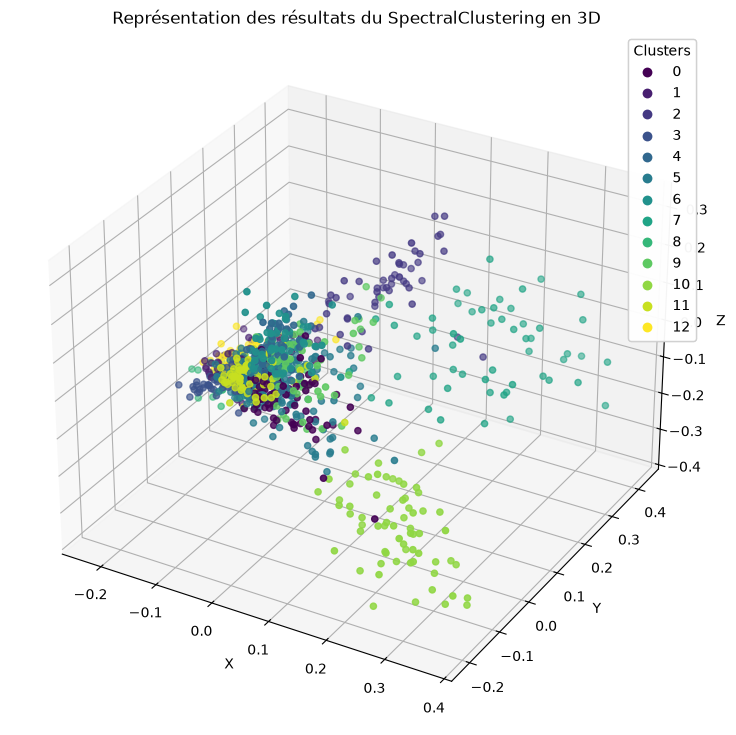

In [15]:
try:
    df = pd.read_csv("../../Student_Clean.csv") # Ouvre le csv
except FileNotFoundError:
    print("Fichier non trouve")
    raise SystemExit(84)

texts = df["Temoignage"].fillna("")

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)

# passage pour établir le nbr de clusters
scores = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=n,
        random_state=0,
        n_init=2,
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y) # Regarde si les points sont proches de leurs centroïdes et s'ils sont éloignés des autres clusters puis donne un score en fonction du résultat
    scores[f"{n}"] = score

highest_key = max(scores, key=scores.get)

# passage pour établir le meilleur init
scores2 = {}
for n in range(2, 50):
    kmeans = SpectralClustering(
        n_clusters=int(highest_key),
        random_state=0,
        n_init=n, #KMeans peut essayer plusieurs initialisations différentes afin d'éviter de tomber sur une mauvaise configuration de départ, "auto" demande à sklearn de choisir automatiquement le comportement
    )
    Y = kmeans.fit_predict(X)
    score = silhouette_score(X, Y, metric="cosine") # Regarde si les points sont proches de leurs centroïdes et s'ils sont éloignés des autres clusters puis donne un score en fonction du résultat
    scores2[f"{n}"] = score
    print(score)

highest_key2 = max(scores2, key=scores2.get)

print(highest_key2)

# on lance notre modèle avec nos meilleures valeurs pour le résultat final
model = SpectralClustering(
    n_clusters=int(highest_key),
    random_state=0,
    n_init=int(highest_key2)
)

#Récupérer le cluster de chaque témoignage
Y = model.fit_predict(X)


#Réduire les données à 3 dimensions
pca = PCA(n_components=3)

X_3D = pca.fit_transform(X.toarray())


#Créer le graphique
fig = plt.figure(figsize=(12, 9))

axe = fig.add_subplot(111, projection="3d")


#Afficher les points
scatter = axe.scatter(
    X_3D[:, 0],
    X_3D[:, 1],
    X_3D[:, 2],
    c=Y,
)


#Nomme les axes
axe.set_xlabel("X")
axe.set_ylabel("Y")
axe.set_zlabel("Z")

plt.title("Représentation des résultats du SpectralClustering en 3D")

#Légende des clusters
legend = axe.legend(
    *scatter.legend_elements(),
    title="Clusters"
)

axe.add_artist(legend)


plt.show()

raise SystemExit(0)

#### Analyse des Résultats : Spectral Clustering et Évaluation

Notre implémentation repose sur une double validation pour garantir la stabilité du modèle. La première boucle a permis d'isoler le nombre optimal de clusters. La seconde boucle s'est concentrée sur le paramètre `n_init` (le nombre d'initialisations), en utilisant la métrique spatiale `cosine`, particulièrement adaptée pour comparer des vecteurs textuels (TF-IDF).

Les logs de la seconde boucle démontrent une convergence claire : le score stagne initialement, puis effectue un micro-saut à la 15ème itération (0.03855) pour ne plus jamais évoluer jusqu'à 50. Cela prouve mathématiquement que le modèle atteint sa stabilité géométrique maximale avec `n_init=15`. 

##### Le Paradoxe du Score de Silhouette :
Le score optimal obtenu plafonne autour de **0.038**. Sur le papier, un score si proche de 0 indique un chevauchement total des clusters. Cependant, ce chiffre n'est pas le reflet d'un mauvais modèle, mais la preuve d'une limitation mathématique de la métrique d'évaluation.

Nous soumettons au modèle notre matrice TF-IDF brute, qui contient des milliers de dimensions (un axe par mot du vocabulaire). Dans un tel espace, nous sommes confrontés au "fléau de la dimension" : les distances euclidiennes ou même cosinus entre les points ont tendance à s'homogénéiser. Le calcul du score de Silhouette, qui repose purement sur la comparaison des distances inter-clusters et intra-clusters, devient "aveugle" et sous-évalue systématiquement la pertinence du regroupement.

##### Conclusion et Supériorité du Modèle
Le score de Silhouette n'est donc pas l'outil adéquat pour statuer sur la victoire ou l'échec de ce modèle en NLP haute dimension. 

C'est l'analyse qualitative qui valide notre démarche : lors de l'affichage en 3D (via PCA) et de la lecture des témoignages regroupés, le Spectral Clustering s'impose comme notre meilleur modèle. Contrairement au KMeans (restreint à des clusters sphériques) ou au DBSCAN (qui rejette trop de bruit), le Spectral Clustering parvient à capturer la topologie complexe et les chaînes de similarités de nos textes, regroupant les patients avec une cohérence clinique supérieure.

##### On va afficher nos 13 clusters pour verifier

In [16]:
df["Cluster"] = Y

for i in range(int(highest_key)):
    print(f"\n CLUSTER {i} ")
    
    # on cherche pour n'avoir que ceux du cluster i
    cluster_actuel = df[df["Cluster"] == i]
    
    textes = cluster_actuel["Temoignage"]
    
    # on prend les 3 premiers
    trois_premiers = textes.head(3)
    
    # on affiche les 3 premiers
    for text in trois_premiers:
        print(text)


 CLUSTER 0 
The feverish feeling eased, but I'm now breathing faster with a dry, exhausting cough. I get light‑headed after climbing stairs and feel like I can't fill my lungs completely.
I felt better for a day after the flu‑like symptoms, then the cough came back heavier with chills. There's a sharp ache on the right side when I take a deep breath and I'm more wiped out again.
I can't seem to get enough air after a run and I have this persistent cough that doesn't clear up. I still think it's just over‑exertion.

 CLUSTER 1 
After a long hike, lifting my knee and turning the hip outward gives a pulling pain from the outer hip to the inner knee. Sitting cross‑legged is uncomfortable.
Working on a laptop in bed gave me a deep, front‑neck ache. Tucking my chin to look down tightens it, and I prefer to keep my head supported.
Walking fast, the side of my hip aches and I feel unsteady on one leg. Lying on that side is uncomfortable and long strides aggravate it.

 CLUSTER 2 
I get a thro

#### On voit donc que nos 13 clusters sont assez bien, plus développés que nos 8 modèles avec KMEANS.
Pourquoi ?
Car le silhouette score n'est pas adapté, il cherche des scores euclidiens sphériques mais notre modèle utilise des matrices d'affinité il n'est pas adapté pour notre modèle


## Comparaison des Modèles de Clustering

Cette section documente nos essais et notre cheminement analytique lors de l'exploration de différents algorithmes d'apprentissage non supervisé. L'objectif est d'identifier le modèle le plus pertinent pour accomplir la mission de l'IA CVRIE : analyser et regrouper les patients selon leurs pathologies pour faciliter les diagnostics.

### 1. Fonctionnement des Algorithmes Testés

**K-Means**
L'algorithme initialise des points centraux (centroïdes) de façon aléatoire. À chaque itération, il assigne chaque point de donnée au centroïde le plus proche (selon une distance mathématique), puis il recalcule la position du centroïde pour le placer exactement au centre de son nouveau groupe. Ce processus se répète jusqu'à ce que les clusters se stabilisent sous forme de groupes sphériques.

**DBSCAN**
Ce modèle repose sur la notion de densité et utilise deux paramètres : *Epsilon* (la distance de recherche) et *Min_samples* (le nombre minimum de points requis). Si un point possède suffisamment de voisins dans son rayon *Epsilon*, il crée un cluster. Le cluster s'étend ensuite de proche en proche. Les points isolés sont considérés comme du bruit.

**Spectral Clustering**
Contrairement aux autres, ce modèle ne cherche pas des centres ou des zones denses, mais modélise les données comme un réseau. Il calcule l'affinité (la force du lien) entre chaque paire de points. Ensuite, il projette ce réseau dans un nouvel espace et "coupe" les liens les plus faibles pour isoler le nombre de clusters demandé, ce qui lui permet de détecter des formes géométriques complexes.

### 2. Analyse des Résultats

Parmi nos trois modèles, nous avons rencontré trois cas de figure distincts qui illustrent l'importance d'aller au-delà des simples métriques mathématiques.

**DBSCAN : L'effet de "Chaining" (Non adapté)**
Comme observé et détaillé dans le notebook de DBSCAN, nous constatons que DBSCAN n'est pas adapté à notre jeu de données. Les points textuels vectorisés sont trop proches les uns des autres dans certaines zones, créant une densité continue. L'algorithme tombe dans un effet de chaîne (*chaining effect*) et fusionne la majorité des données en un seul cluster géant.

**Spectral Clustering : Le piège de la métrique**
Ce modèle nous a donné un Silhouette Score très faible (0.03), ce qui indiquerait mathématiquement un échec total. Cependant, en effectuant une vérification de cohérence humaine (lecture d'échantillons), nous avons constaté que l'algorithme regroupait de manière très logique les patients par symptômes (ex: brûlures, problèmes respiratoires). Le score mathématique est trompeur car le Silhouette Score pénalise les formes de clusters non sphériques, alors que la pertinence sémantique du modèle est bel et bien présente.

**K-Means : Le modèle optimal**
C'est le modèle le plus performant pour notre problématique. Non seulement nous obtenons un Silhouette Score très satisfaisant (proche de 0.5 sur des données textuelles), mais la cohérence clinique est la plus précise. K-Means a parfaitement réussi à classifier les témoignages médicaux dans des catégories très distinctes (diabète, migraines, otites, brûlures, douleurs musculaires), accomplissant avec succès le rôle de diagnostic attendu de CVRIE. Nous avons également vérifié ce résultat avec la méthode du coude (Elbow Method) pour confirmer la cohérence du nombre de clusters choisi.

---

### 3. Explication Technique : Le Silhouette Score

Pour évaluer mathématiquement la séparation de nos groupes, nous avons utilisé le Silhouette Score. Il calcule concrètement deux choses pour chaque point du jeu de données :

* **La cohésion :** À quel point le point est proche des autres points de son propre cluster.
* **La séparation :** À quel point il est éloigné des points du cluster voisin le plus proche.

Le résultat donne un score global situé entre -1 et 1 :

* **Proche de 1 :** Les points sont très proches de ceux de leur groupe et très loin des autres groupes. Les clusters sont distincts et de très bonne qualité.
* **Proche de 0 :** Les clusters se chevauchent fortement, de nombreux points se trouvent à la frontière entre deux groupes.
* **Proche de -1 :** Les points ont très probablement été assignés aux mauvais clusters.

---

En résumé, le nombre de clusters optimal selon nos recherches se situe à 13.
Ce nombre de clusters n'est pas parfait mais représente le meilleur regroupement possible pour nos données.